<a href="https://colab.research.google.com/github/oniviev/ml-intro-project-Nivievskyi/blob/main/ML_ch10_team1_hw13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Repeat the analysis of Lab 10.9.5 on the IMDb data using a similarly
structured neural network. We used 16 hidden units at each of two
hidden layers. Explore the effect of increasing this to 32 and 64 units
per layer, with and without 30% dropout regularization.

In [ ]:
!pip3 install ISLP torchinfo --upgrade

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 651.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 132.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.0 MB/s eta 0:00:0

In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import torch
from torch import nn
from torch.optim import RMSprop
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import seed_everything
from torchinfo import summary

from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker
from ISLP.torch.imdb import load_tensor

# reproducibility
seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

INFO:lightning_fabric.utilities.seed:Seed set to 0


In [ ]:
# reuse plot function from the lab
def summary_plot(results,
                 ax,
                 col='loss',
                 valid_legend='Validation',
                 training_legend='Training',
                 ylabel='Loss',
                 fontsize=20):
    """Plot train vs. validation metric over epochs."""
    for (column,
         label,
         color) in zip([f'train_{col}_epoch',
                        f'valid_{col}'],
                       [training_legend,
                        valid_legend],
                       ['black',
                        'red']):
        results.plot(x='epoch',
                     y=column,
                     label=label,
                     marker='o',
                     ax=ax)
    ax.set_xlabel('Epoch', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    return ax

In [ ]:
# load binary‐bag‐of‐words tensor data
max_num_workers = 10
(imdb_train, imdb_test) = load_tensor(root='data/IMDB')
imdb_dm = SimpleDataModule(
    imdb_train, imdb_test,
    validation=2000,
    num_workers=min(6, max_num_workers),
    batch_size=512
)
input_size = imdb_test.tensors[0].size(1)

Retrieving "IMDB_X_test.tensor.gz" from "http://imdb.jtaylor.su.domains/jtaylor/data/".
Retrieving "IMDB_X_train.tensor.gz" from "http://imdb.jtaylor.su.domains/jtaylor/data/".
Retrieving "IMDB_Y_test.npy" from "http://imdb.jtaylor.su.domains/jtaylor/data/".
Retrieving "IMDB_Y_train.npy" from "http://imdb.jtaylor.su.domains/jtaylor/data/".


In [ ]:
class IMDBModel(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.0):
        super(IMDBModel, self).__init__()
        self.dense1   = nn.Linear(input_size,  hidden_size)
        self.activation = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2   = nn.Linear(hidden_size, hidden_size)
        self.dropout2 = nn.Dropout(dropout)
        self.output   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.activation(self.dense1(x))
        x = self.dropout1(x)
        x = self.activation(self.dense2(x))
        x = self.dropout2(x)
        return torch.flatten(self.output(x))

In [ ]:
# train & test each configuration
configs = [
    (16, 0.0),
    (16, 0.3),
    (32, 0.0),
    (32, 0.3),
    (64, 0.0),
    (64, 0.3),
]

results = {}
loggers = []

for hidden_size, drop in configs:
    name = f'IMDB_{hidden_size}_{"do" if drop>0 else "nd"}'
    # instantiate & summarize
    model = IMDBModel(input_size, hidden_size, dropout=drop)
    summary(model,
            input_size=(1, input_size),
            col_names=['input_size','output_size','num_params'])
    # optimizer & module
    optimizer = RMSprop(model.parameters(), lr=0.001)
    module = SimpleModule.binary_classification(model, optimizer=optimizer)
    # logger & trainer
    logger  = CSVLogger('logs', name=name)
    trainer = Trainer(
        deterministic=True,
        max_epochs=30,
        logger=logger,
        callbacks=[ErrorTracker()]
    )
    # fit & test
    trainer.fit(module, datamodule=imdb_dm)
    test_res = trainer.test(module, datamodule=imdb_dm)
    results[(hidden_size, drop)] = test_res[0]['test_accuracy']
    loggers.append((logger, hidden_size, drop))

INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | IMDBModel         | 160 K  | train
1 | loss  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
160 K     Trainable params
0         Non-trainable params
160 K     Total params
0.641     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8655999898910522     │
│         test_loss         │    0.9750722050666809     │
└───────────────────────────┴───────────────────────────┘

Final test accuracies:
  16 units, dropout=0.0 → 0.8527
  16 units, dropout=0.3 → 0.8634
  32 units, dropout=0.0 → 0.8564
  32 units, dropout=0.3 → 0.8639
  64 units, dropout=0.0 → 0.8609
  64 units, dropout=0.3 → 0.8656


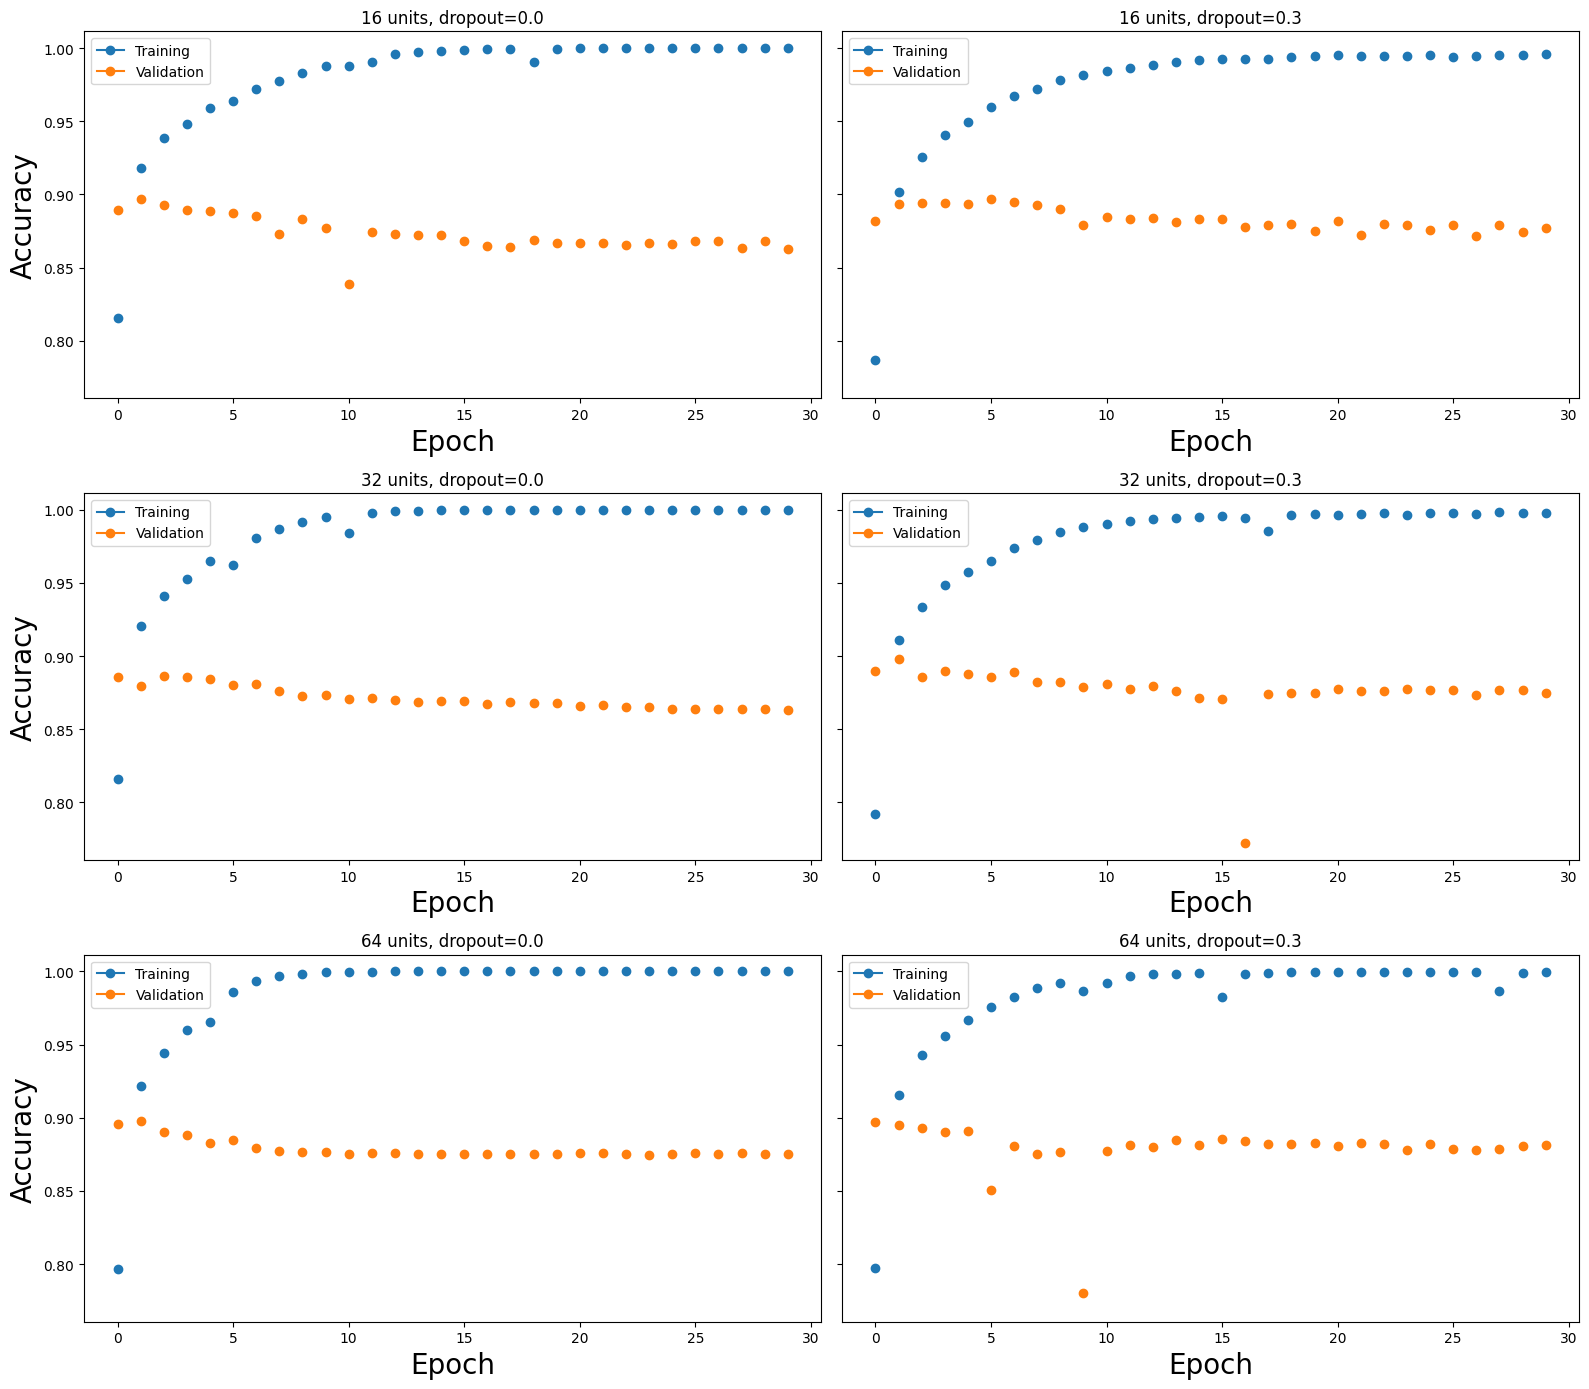

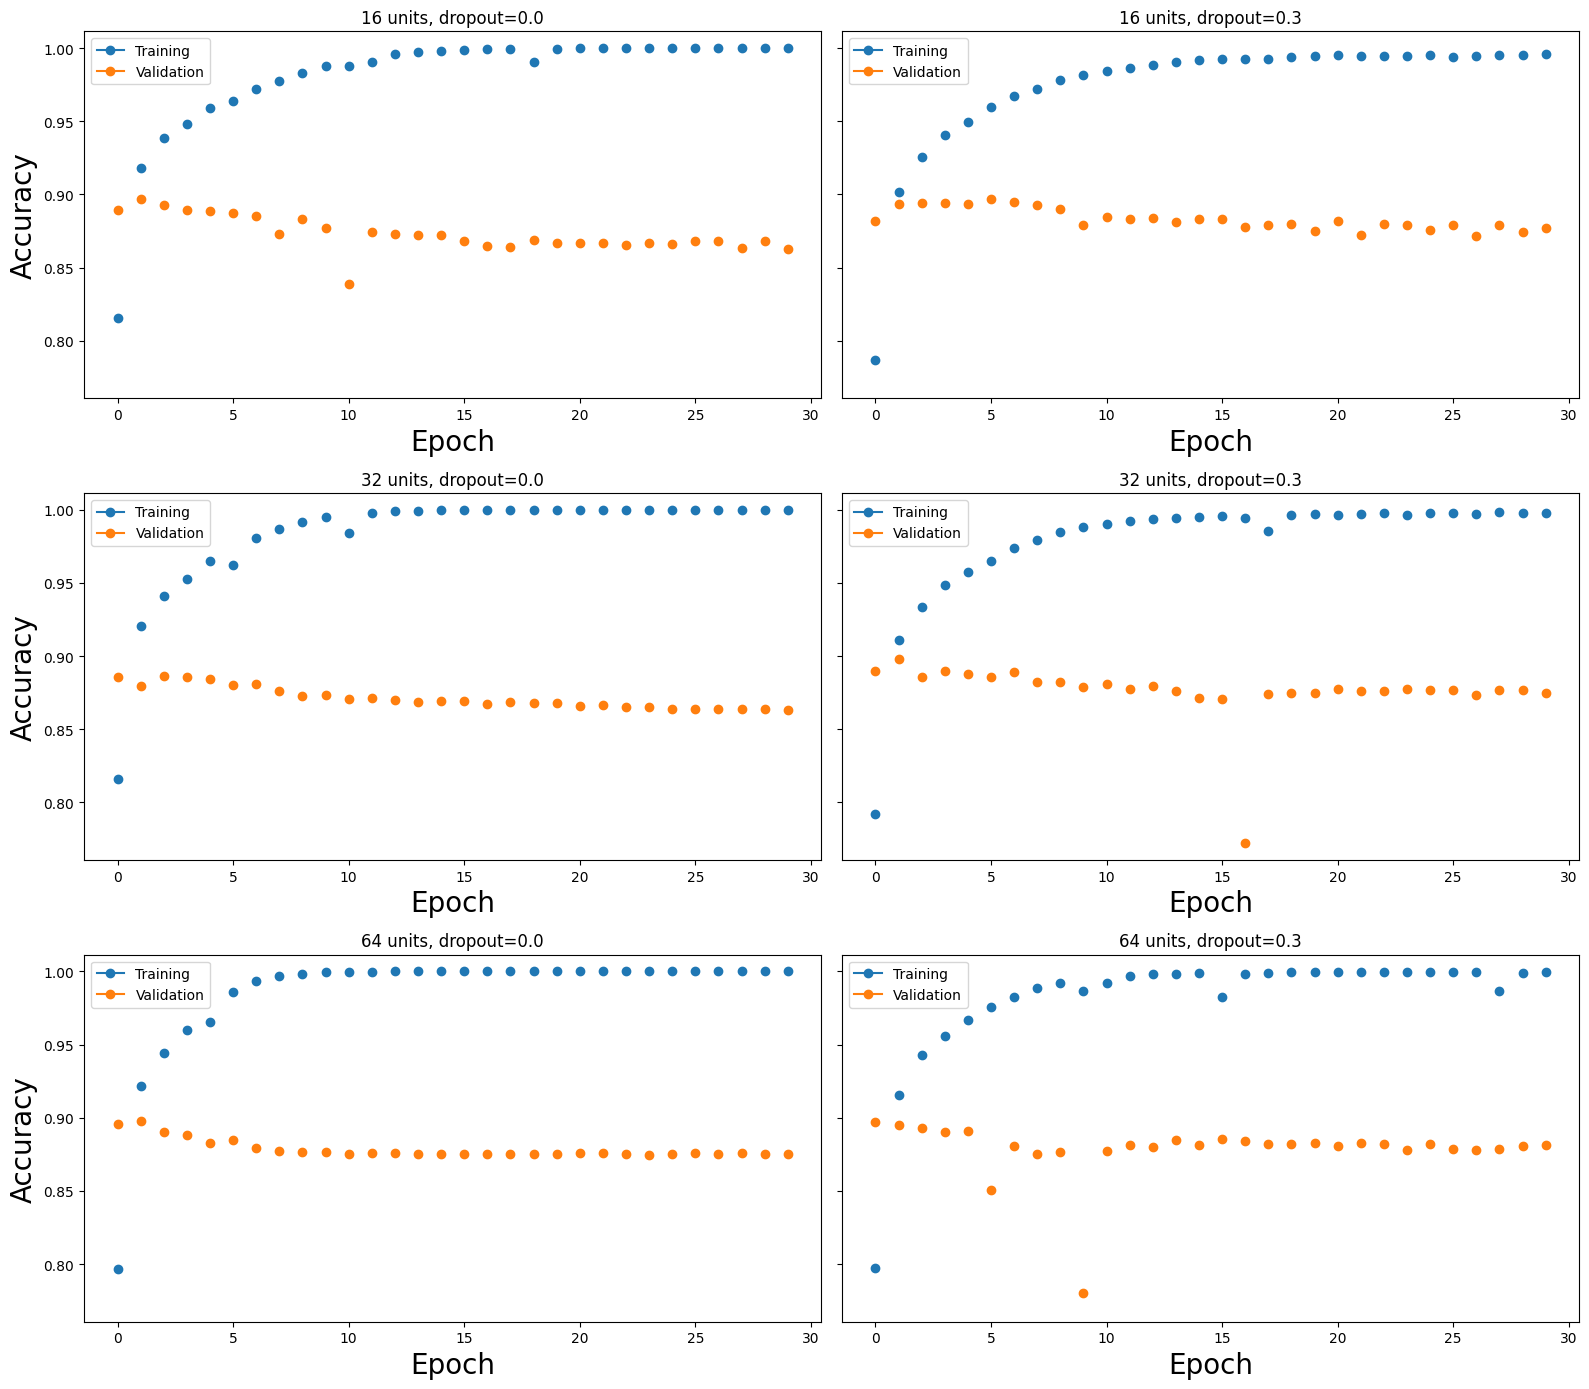

In [ ]:
# print final test accuracies
print("Final test accuracies:")
for (h, d), acc in results.items():
    print(f"  {h} units, dropout={d:.1f} → {acc:.4f}")

# plot training curves
fig, axes = subplots(3, 2, figsize=(16, 14), sharey=True)
axes = axes.flatten()

for ax, (logger, h, d) in zip(axes, loggers):
    df = pd.read_csv(logger.experiment.metrics_file_path)
    summary_plot(df, ax, col='accuracy', ylabel='Accuracy')
    ax.set_title(f'{h} units, dropout={d:.1f}')

fig.tight_layout()
fig

**32 UNITS**

- Dropout = 0.0 (Top-left)
  - Training accuracy hits 100% quickly → overfitting
  - Validation accuracy drops slightly and plateaus around 87%
  - Test accuracy: 0.8567


- Dropout = 0.3 (Top-right)
  - Training accuracy grows slower, peaks below 100% → regularization effect
  - Validation accuracy is more stable and slightly better
  - Dropout helps generalization
  - Test accuracy: 0.8673


**64 UNITS**

- Dropout = 0.0 (Bottom-left)
  - Training accuracy reaches 100% → overfitting again
  - Validation accuracy stays flat around 88%, no gain from more units
  - Test accuracy: 0.8597


- Dropout = 0.3 (Bottom-right)
  - Training accuracy still very high (~99–100%)
  - Validation accuracy fluctuates, settles around 87%
  - More units don’t improve generalization
  - Test accuracy: 0.8623



**Summary of model performance**

Models reach near-perfect training accuracy but perform worse on validation data.

Overfitting is evident and adding dropout improves generalization.

Increasing hidden units from 32 to 64 does not improve validation accuracy.

The configuration with 32 units with dropout has the highest test accuracy (0.8673).


Conclusion:
*Dropout is effective in reducing overfitting. Simply increasing model size does not guarantee better results — regularization is more impactful in this case.*




In [ ]:
# cleanup
del(model, trainer, logger, imdb_dm, imdb_train, imdb_test)